# High-density subtube exploration

This notebook explores how to construct one or more high-density subtubes inside the existing 2004 MN4 (Apophis) uncertainty tube. It uses precomputed states, so it does not repeat orbit fitting or propagation.

## Processing steps

1. **Load cached variant states.** The state cache contains the 3D position and velocity of 1,000 propagated orbit variants at 372 tube timestamps, together with their stable target IDs.
2. **Load the original cut planes.** The existing tube JSON supplies the center and timestamp of every tube cross-section. JSON centers are converted from metres to kilometres to match the cached states.
3. **Reconstruct each cut plane.** The plane center comes from the tube JSON, and its normal is estimated from the median velocity of all valid variants at that timestamp.
4. **Intersect every variant with the plane.** Each trajectory is locally approximated by its cached position and velocity line. Moving along that line until it reaches the plane removes most of the along-track/time-lag variation.
5. **Project intersections into 2D.** The 3D intersection points are expressed in a local two-dimensional coordinate system lying in the cut plane. These are the points used for density analysis.
6. **Estimate the density field.** The projected points are accumulated into the same Gaussian-smoothed density image used by the existing NEOviz texture pipeline.
7. **Extract highest-density regions.** A probability-mass threshold selects the highest-density region (for example, the smallest area containing 50% of the density). Connected-component labeling allows a cut plane to contain multiple separate dense regions.
8. **Track regions through time.** In a later stage, regions on adjacent cut planes will be connected using shared variant target IDs and spatial continuity. The resulting tracks, including possible splits and merges, will define the high-density subtubes.

The current first milestone is to validate steps 1–7 on individual cut planes before implementing region tracking and subtube export.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "revision").exists():
    REPO_ROOT = Path.cwd().parent

STATE_CACHE = REPO_ROOT / "revision" / "cache" / "2004_MN4_cutplane_states.npz"
TUBE_JSON = REPO_ROOT / "data" / "B612_data" / "Test" / "2004 MN4" / "tube_2004_MN4.json"

STATE_CACHE

PosixPath('/mnt/c/Users/flan/Documents/NEOviz/NEOviz_repo/revision/cache/2004_MN4_cutplane_states.npz')

In [2]:
cache = np.load(STATE_CACHE, allow_pickle=False)

cutplane_indices = cache["cutplane_indices"]
times_utc = cache["times_utc"]
times_et = cache["times_et"]
target_ids = cache["target_ids"]
positions_km = cache["positions_km"]
velocities_km_s = cache["velocities_km_s"]

print("arrays:", cache.files)
print("cut planes:", len(cutplane_indices))
print("variants:", len(target_ids))
print("positions_km:", positions_km.shape, positions_km.dtype)
print("velocities_km_s:", velocities_km_s.shape, velocities_km_s.dtype)
print("first time:", times_utc[0])
print("last time:", times_utc[-1])

arrays: ['cutplane_indices', 'times_utc', 'times_et', 'target_ids', 'positions_km', 'velocities_km_s']
cut planes: 372
variants: 1000
positions_km: (372, 1000, 3) float64
velocities_km_s: (372, 1000, 3) float64
first time: 2029-03-30T00:00:00.000
last time: 2029-04-30T00:00:00.000


## Compare the first five cut planes

These cells repeat the intersection, projection, and 30% highest-density detection for the first five cached cut planes and display them together. They can run immediately after the cache-loading cell above.

In [3]:
import sys

for path in (REPO_ROOT, REPO_ROOT / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from density_tube_generation import (
    analyze_density_cache_index,
    get_state_cloud_by_cache_index,
    get_state_cloud_by_cutplane_index,
    load_cutplanes,
)

valid_by_time = (
    np.isfinite(positions_km).all(axis=2)
    & np.isfinite(velocities_km_s).all(axis=2)
)
cutplanes = load_cutplanes(TUBE_JSON)


first_five_mass_fraction = 0.3
first_five_density_results = [
    analyze_density_cache_index(
        index,
        cutplanes,
        cutplane_indices,
        positions_km,
        velocities_km_s,
        target_ids,
        mass_fraction=first_five_mass_fraction,
        resolution=128,
        minimum_region_members=10,
    )
    for index in range(min(5, len(cutplane_indices)))
]

for analysis in first_five_density_results:
    result = analysis["density"]
    retained_mass = sum(region.mass for region in result.regions)
    print(
        f"Cut plane {analysis['cutplane_index']}: "
        f"regions={len(result.regions)}, "
        f"retained mass={retained_mass:.2%}"
    )

Cut plane 0: regions=2, retained mass=30.14%
Cut plane 1: regions=2, retained mass=30.01%
Cut plane 2: regions=2, retained mass=30.13%
Cut plane 3: regions=2, retained mass=30.12%
Cut plane 4: regions=2, retained mass=30.11%


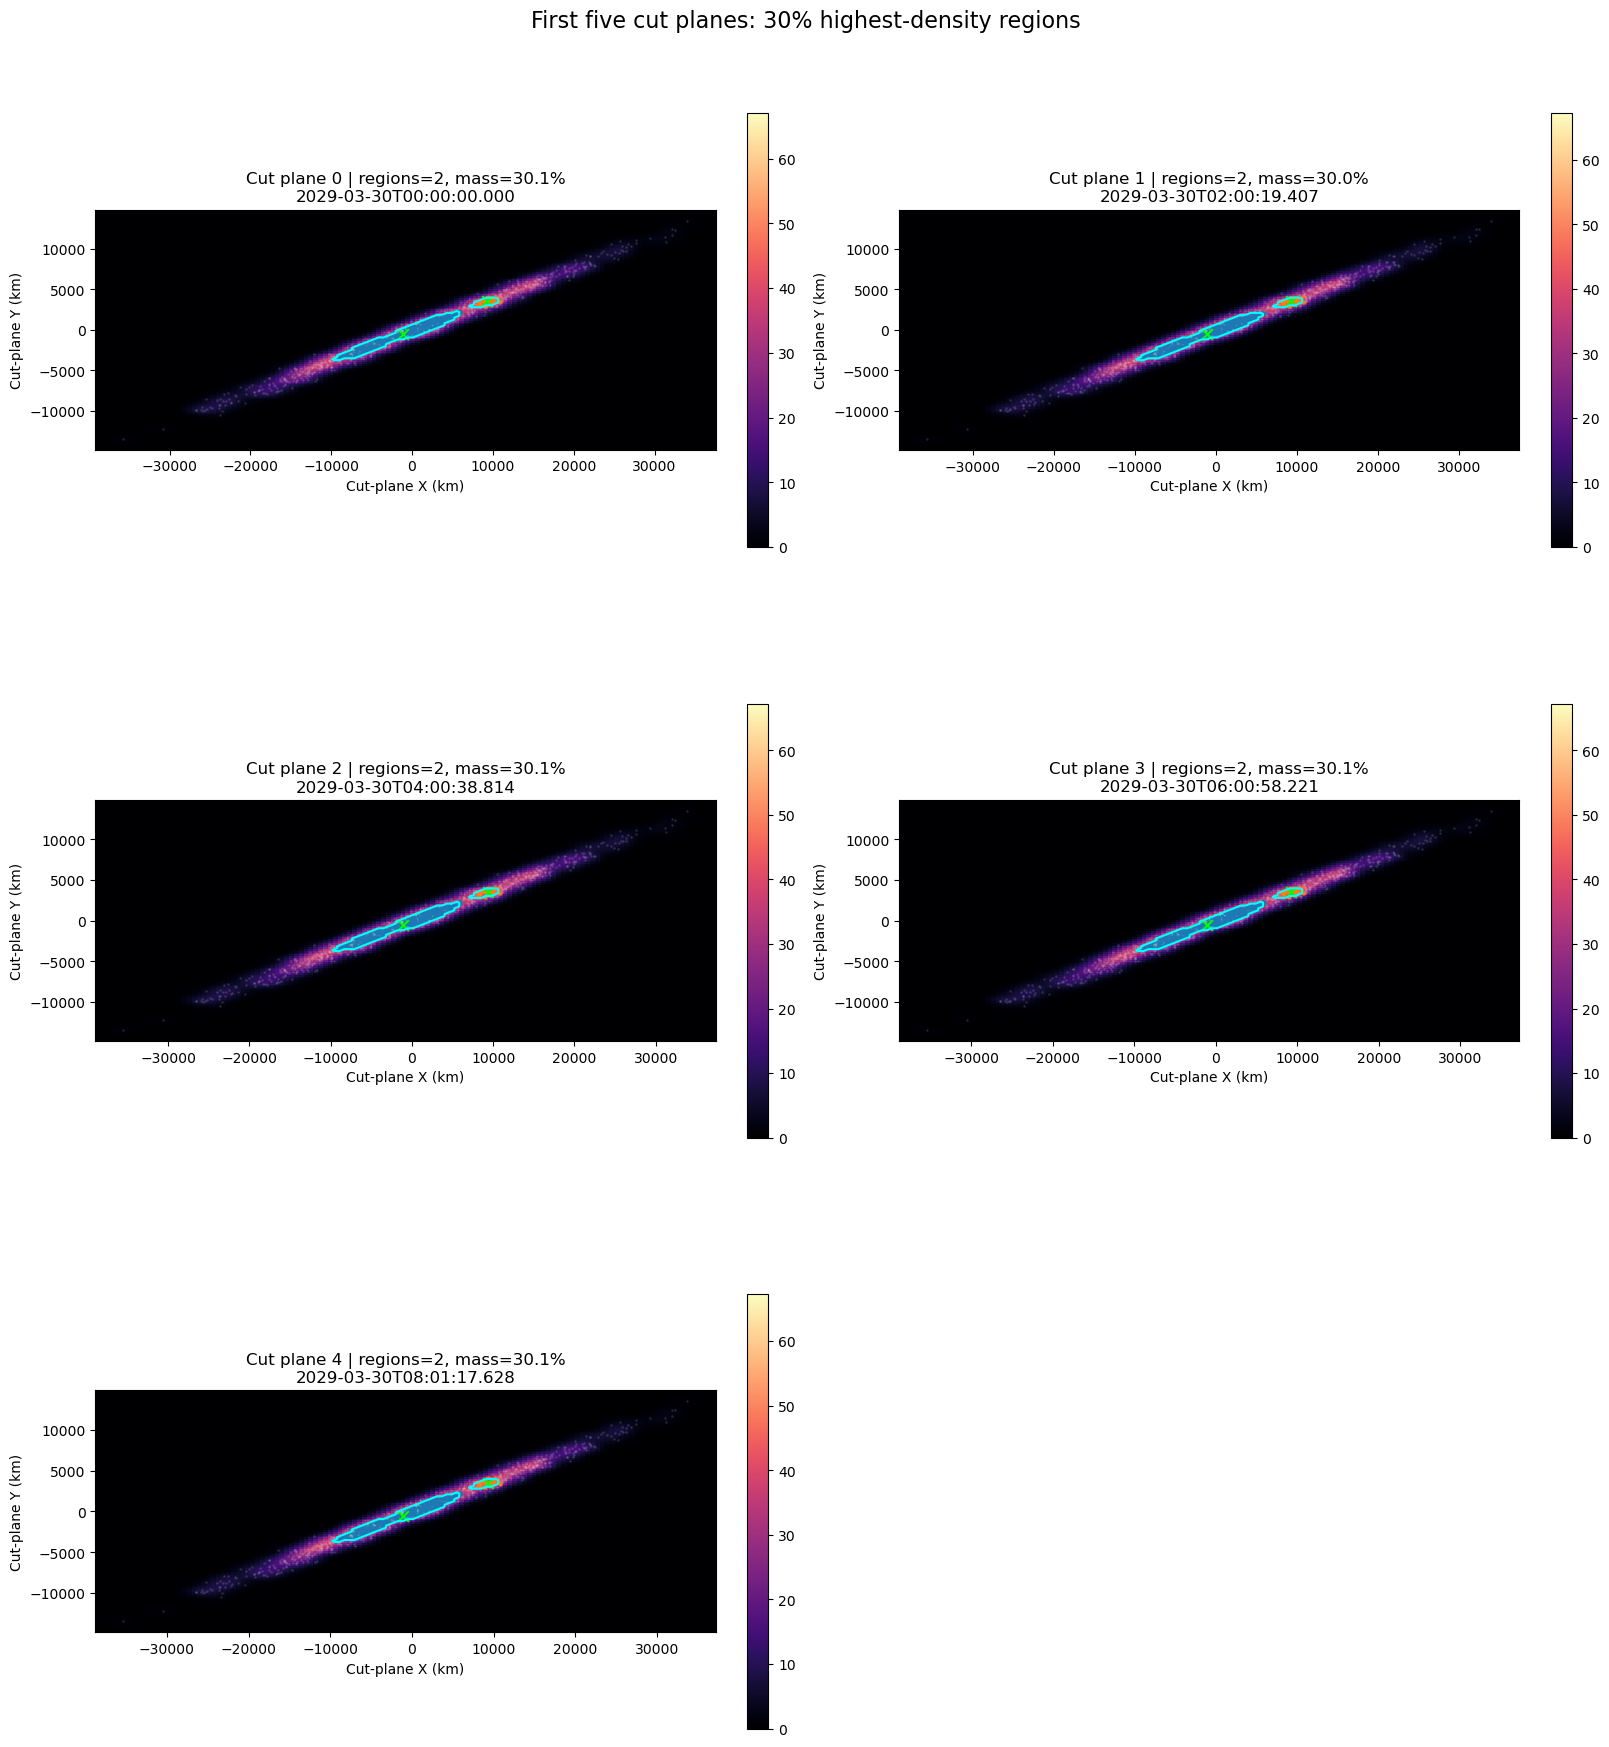

In [4]:
figure, axes = plt.subplots(
    3,
    2,
    figsize=(16, 18),
    constrained_layout=True,
)
axes = axes.ravel()

for axes_index, analysis in enumerate(first_five_density_results):
    ax = axes[axes_index]
    result = analysis["density"]
    projected_points = analysis["points_2d_km"]
    selected_cutplane = analysis["cutplane"]

    extent = (
        result.range_x[0],
        result.range_x[1],
        result.range_y[0],
        result.range_y[1],
    )
    density_image = ax.imshow(
        result.density_matrix,
        origin="lower",
        extent=extent,
        cmap="magma",
        aspect="equal",
        interpolation="nearest",
    )

    region_mask = np.ma.masked_where(
        result.component_labels == 0,
        result.component_labels,
    )
    ax.imshow(
        region_mask,
        origin="lower",
        extent=extent,
        cmap="cool",
        aspect="equal",
        interpolation="nearest",
        alpha=0.45,
    )

    selected_mask = result.component_labels > 0
    if np.any(selected_mask) and not np.all(selected_mask):
        grid_x = np.linspace(
            result.range_x[0],
            result.range_x[1],
            result.component_labels.shape[1],
        )
        grid_y = np.linspace(
            result.range_y[0],
            result.range_y[1],
            result.component_labels.shape[0],
        )
        ax.contour(
            grid_x,
            grid_y,
            selected_mask,
            levels=[0.5],
            colors="cyan",
            linewidths=1.5,
        )

    outside = result.point_labels == 0
    ax.scatter(
        projected_points[outside, 0],
        projected_points[outside, 1],
        s=3,
        color="white",
        alpha=0.15,
        linewidths=0,
    )
    for region in result.regions:
        members = region.point_indices
        ax.scatter(
            projected_points[members, 0],
            projected_points[members, 1],
            s=8,
            alpha=0.8,
            linewidths=0,
        )
        ax.scatter(
            region.centroid_2d[0],
            region.centroid_2d[1],
            marker="x",
            s=60,
            linewidths=1.5,
            color="lime",
        )

    retained_mass = sum(region.mass for region in result.regions)
    ax.set_title(
        f"Cut plane {analysis['cutplane_index']} | "
        f"regions={len(result.regions)}, mass={retained_mass:.1%}\n"
        f"{selected_cutplane.time_utc}"
    )
    ax.set_xlabel("Cut-plane X (km)")
    ax.set_ylabel("Cut-plane Y (km)")
    figure.colorbar(density_image, ax=ax, shrink=0.75)

for unused_axes in axes[len(first_five_density_results):]:
    unused_axes.set_visible(False)

figure.suptitle(
    f"First five cut planes: {first_five_mass_fraction:.0%} highest-density regions",
    fontsize=16,
)
plt.show()

In [5]:
valid_by_time = np.isfinite(positions_km).all(axis=2) & np.isfinite(velocities_km_s).all(axis=2)
valid_counts = valid_by_time.sum(axis=1)

print("valid count min/max:", valid_counts.min(), valid_counts.max())
for i, count in enumerate(valid_counts):
    if count != len(target_ids):
        print(f"cutplane_index={cutplane_indices[i]}, time={times_utc[i]}, valid={count}/{len(target_ids)}")

valid count min/max: 0 1000
cutplane_index=371, time=2029-04-30T00:00:00.000, valid=0/1000


In [6]:
cloud = get_state_cloud_by_cache_index(
    0, cutplane_indices, times_utc, target_ids, positions_km, velocities_km_s
)
cloud["time_utc"], cloud["positions_km"].shape, cloud["velocities_km_s"].shape

('2029-03-30T00:00:00.000', (1000, 3), (1000, 3))

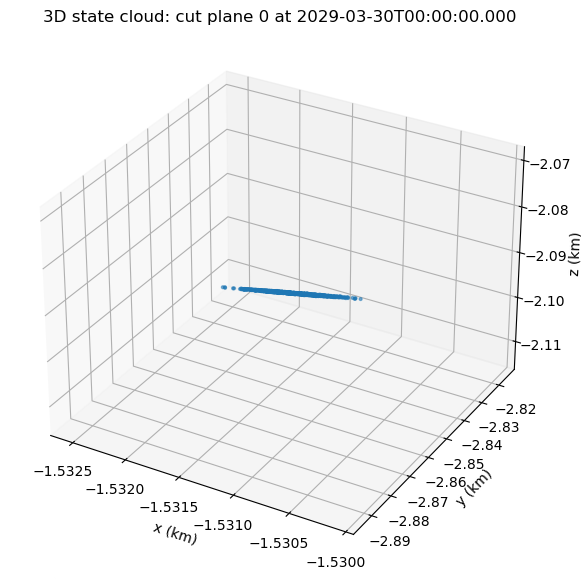

In [7]:
cache_index_to_plot = 0
cloud = get_state_cloud_by_cache_index(
    cache_index_to_plot,
    cutplane_indices,
    times_utc,
    target_ids,
    positions_km,
    velocities_km_s,
)
points = cloud["positions_km"]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=4, alpha=0.55)
ax.set_title(f"3D state cloud: cut plane {cloud['cutplane_index']} at {cloud['time_utc']}")
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_zlabel("z (km)")
plt.show()

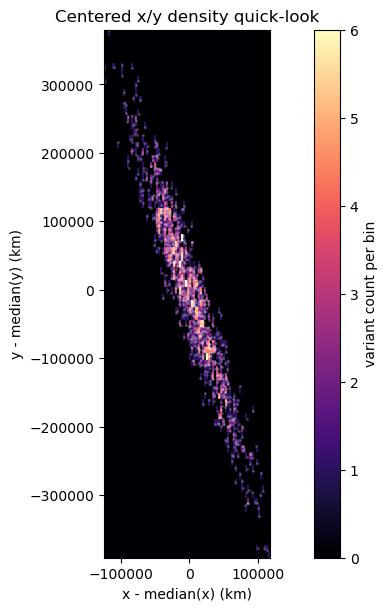

In [8]:
# A centered 2D quick-look of the 3D cloud, using x/y only.
# This is not the final cut-plane projection; it is just a fast sanity view.
centered = points - np.nanmedian(points, axis=0)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
hist = ax.hist2d(centered[:, 0], centered[:, 1], bins=80, cmap="magma")
fig.colorbar(hist[3], ax=ax, label="variant count per bin")
ax.scatter(centered[:, 0], centered[:, 1], s=4, c="white", alpha=0.25, linewidths=0)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Centered x/y density quick-look")
ax.set_xlabel("x - median(x) (km)")
ax.set_ylabel("y - median(y) (km)")
plt.show()

## Detect the high-density region

The quick-look above uses global X/Y coordinates. The following cells instead reconstruct the actual tube cut plane, intersect every locally linearized variant trajectory with it, project those intersections into 2D, and highlight the connected region or regions containing the densest 30% of the texture mass.

In [9]:
import sys

for path in (REPO_ROOT, REPO_ROOT / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from density_tube_generation import analyze_density_cache_index, load_cutplanes

In [10]:
cutplanes = load_cutplanes(TUBE_JSON)

# Change this value to inspect a different cached cut plane.
density_cache_index = 0
density_mass_fraction = 0.3
analysis = analyze_density_cache_index(
    density_cache_index,
    cutplanes,
    cutplane_indices,
    positions_km,
    velocities_km_s,
    target_ids,
    mass_fraction=density_mass_fraction,
    resolution=128,
    minimum_region_members=10,
)

cutplane_index = analysis.cutplane_index
cutplane = analysis.cutplane
points_2d_km = analysis.points_2d_km
projected_target_ids = analysis.target_ids
intersections_km = analysis.intersections_km
time_offsets_s = analysis.time_offsets_s
plane_normal = analysis.plane_normal

print("Cache row:", density_cache_index)
print("Tube cut-plane index:", cutplane_index)
print("Time:", cutplane.time_utc)
print("Projected intersections:", len(points_2d_km))

Cache row: 0
Tube cut-plane index: 0
Time: 2029-03-30T00:00:00.000
Projected intersections: 1000


In [11]:
density_result = analysis.density

retained_mass = sum(region.mass for region in density_result.regions)
print("Density threshold:", density_result.threshold)
print("Detected regions:", len(density_result.regions))
print(f"Retained density mass: {retained_mass:.2%}")

for region in density_result.regions:
    print(
        f"Region {region.label}: "
        f"members={len(region.point_indices)}, "
        f"mass={region.mass:.2%}, "
        f"centroid={region.centroid_2d}"
    )

Density threshold: 37.9971696536135
Detected regions: 2
Retained density mass: 30.14%
Region 1: members=378, mass=26.94%, centroid=[-1103.52469131  -505.18194624]
Region 2: members=49, mass=3.20%, centroid=[9327.6755488  3533.72402528]


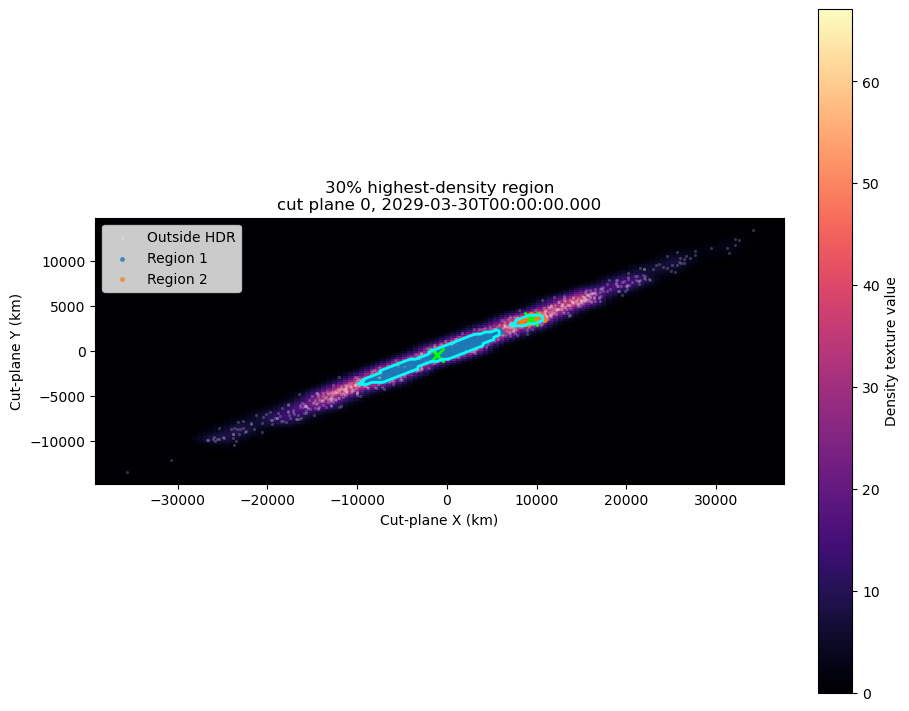

In [12]:
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)

extent = (
    density_result.range_x[0],
    density_result.range_x[1],
    density_result.range_y[0],
    density_result.range_y[1],
)

density_image = ax.imshow(
    density_result.density_matrix,
    origin="lower",
    extent=extent,
    cmap="magma",
    aspect="equal",
    interpolation="nearest",
)
fig.colorbar(density_image, ax=ax, label="Density texture value")

# Overlay the exact retained high-density grid cells.
region_mask = np.ma.masked_where(
    density_result.component_labels == 0,
    density_result.component_labels,
)
ax.imshow(
    region_mask,
    origin="lower",
    extent=extent,
    cmap="cool",
    aspect="equal",
    interpolation="nearest",
    alpha=0.45,
)

# Draw a cyan outline around the selected cells.
if density_result.regions:
    grid_x = np.linspace(
        density_result.range_x[0],
        density_result.range_x[1],
        density_result.component_labels.shape[1],
    )
    grid_y = np.linspace(
        density_result.range_y[0],
        density_result.range_y[1],
        density_result.component_labels.shape[0],
    )
    ax.contour(
        grid_x,
        grid_y,
        density_result.component_labels > 0,
        levels=[0.5],
        colors="cyan",
        linewidths=2,
    )

outside = density_result.point_labels == 0
ax.scatter(
    points_2d_km[outside, 0],
    points_2d_km[outside, 1],
    s=5,
    color="white",
    alpha=0.2,
    linewidths=0,
    label="Outside HDR",
)

for region in density_result.regions:
    members = region.point_indices
    ax.scatter(
        points_2d_km[members, 0],
        points_2d_km[members, 1],
        s=12,
        alpha=0.8,
        linewidths=0,
        label=f"Region {region.label}",
    )
    ax.scatter(
        region.centroid_2d[0],
        region.centroid_2d[1],
        marker="x",
        s=100,
        linewidths=2,
        color="lime",
    )

ax.set_title(
    f"{density_mass_fraction:.0%} highest-density region\n"
    f"cut plane {cutplane_index}, {cutplane.time_utc}"
)
ax.set_xlabel("Cut-plane X (km)")
ax.set_ylabel("Cut-plane Y (km)")
ax.legend()
plt.show()

## Extract iso-density contour vertices

The cyan outlines above follow the binary connected-component mask. For subtube geometry, the following cells contour the continuous density matrix directly at its HDR threshold. Matplotlib interpolates the threshold crossing between pixels and returns ordered subpixel vertices for every contour. The resulting coordinates are still 2D cut-plane coordinates; transforming and connecting them in 3D is a later step.

In [13]:
from density_tube_generation import extract_iso_density_contours


first_five_iso_contours = [
    extract_iso_density_contours(analysis["density"])
    for analysis in first_five_density_results
]

for analysis, contours in zip(first_five_density_results, first_five_iso_contours):
    closed_count = sum(contour["is_closed"] for contour in contours)
    areas = [contour["area_km2"] for contour in contours if contour["is_closed"]]
    print(
        f"Cut plane {analysis['cutplane_index']}: "
        f"{len(contours)} contours, {closed_count} closed, "
        f"areas (km^2)={np.round(areas, 3)}"
    )

Cut plane 0: 2 contours, 2 closed, areas (km^2)=[19433053.082  2581542.778]
Cut plane 1: 2 contours, 2 closed, areas (km^2)=[19148421.956  2464829.418]
Cut plane 2: 2 contours, 2 closed, areas (km^2)=[19201830.531  2416831.254]
Cut plane 3: 2 contours, 2 closed, areas (km^2)=[19076128.47   2376205.464]
Cut plane 4: 2 contours, 2 closed, areas (km^2)=[18959406.486  2337384.18 ]


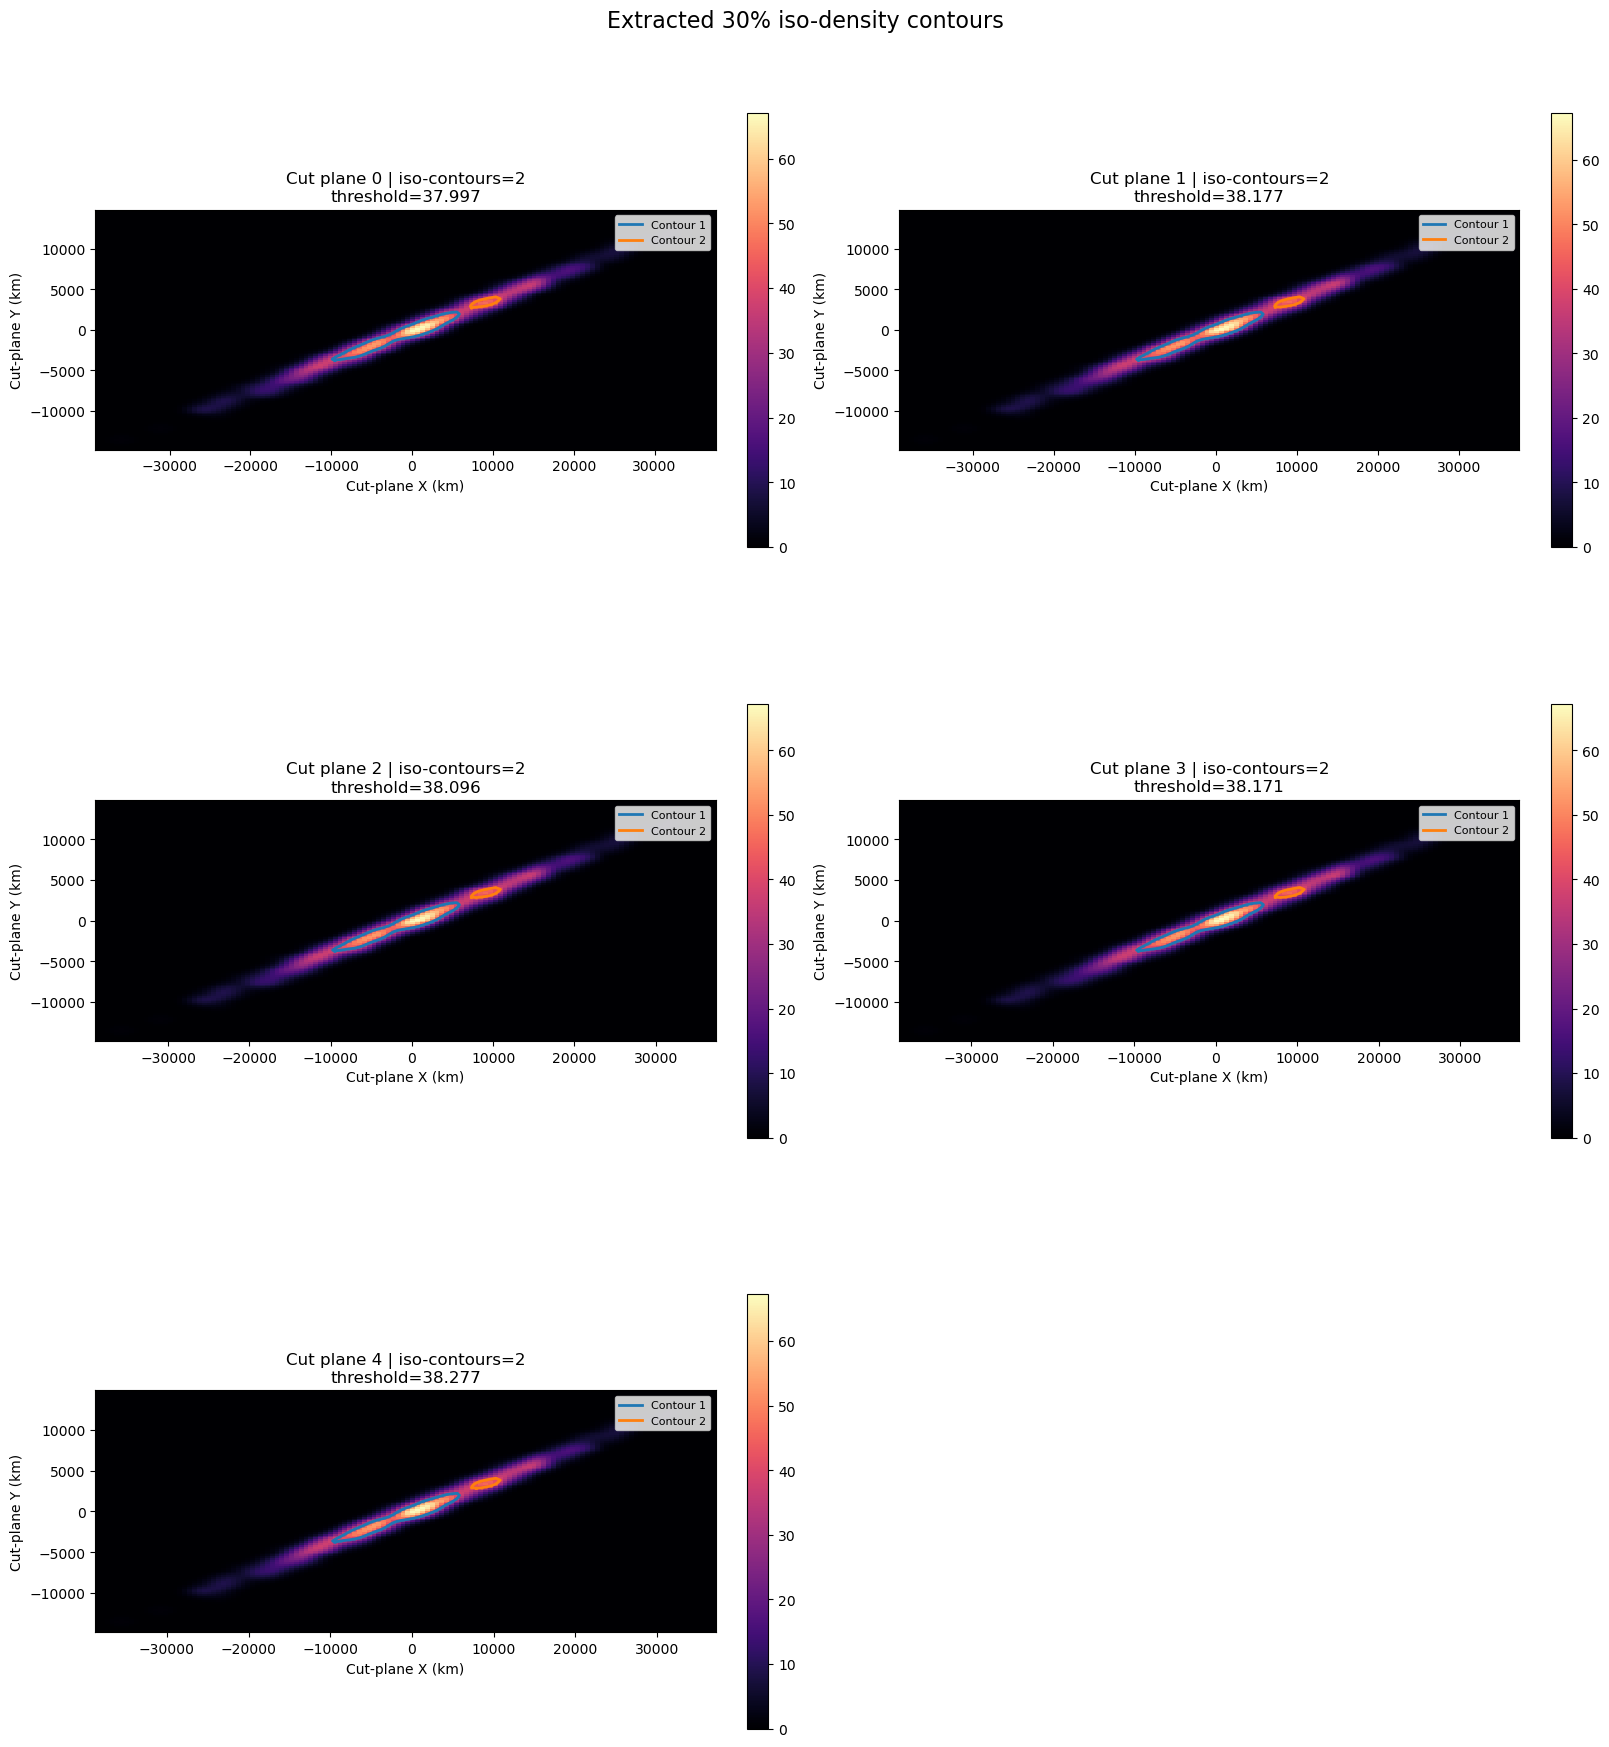

In [14]:
figure, axes = plt.subplots(
    3,
    2,
    figsize=(16, 18),
    constrained_layout=True,
)
axes = axes.ravel()

for axes_index, (analysis, contours) in enumerate(
    zip(first_five_density_results, first_five_iso_contours)
):
    ax = axes[axes_index]
    result = analysis["density"]
    extent = (
        result.range_x[0],
        result.range_x[1],
        result.range_y[0],
        result.range_y[1],
    )
    density_image = ax.imshow(
        result.density_matrix,
        origin="lower",
        extent=extent,
        cmap="magma",
        aspect="equal",
        interpolation="nearest",
    )

    for contour_index, contour in enumerate(contours, start=1):
        vertices = contour["vertices_2d_km"]
        line_style = "-" if contour["is_closed"] else "--"
        ax.plot(
            vertices[:, 0],
            vertices[:, 1],
            linestyle=line_style,
            linewidth=2,
            label=f"Contour {contour_index}",
        )
        ax.scatter(
            vertices[:, 0],
            vertices[:, 1],
            s=4,
            alpha=0.35,
            linewidths=0,
        )

    ax.set_title(
        f"Cut plane {analysis['cutplane_index']} | "
        f"iso-contours={len(contours)}\n"
        f"threshold={result.threshold:.3f}"
    )
    ax.set_xlabel("Cut-plane X (km)")
    ax.set_ylabel("Cut-plane Y (km)")
    if contours:
        ax.legend(loc="best", fontsize=8)
    figure.colorbar(density_image, ax=ax, shrink=0.75)

for unused_axes in axes[len(first_five_density_results):]:
    unused_axes.set_visible(False)

figure.suptitle(
    f"Extracted {first_five_mass_fraction:.0%} iso-density contours",
    fontsize=16,
)
plt.show()

## Associate contours with components and validate trajectory support

Contour extraction only returns geometric threshold boundaries. Association determines which retained connected component is enclosed by each boundary. Point validation then requires a projected trajectory to both have that component's grid label and lie geometrically inside the contour. Closed contours with no retained component or too few supporting trajectories are rejected. Stable target IDs are preserved for tracking the validated region into the next cut plane.

In [15]:
from density_tube_generation import associate_and_validate_contours


minimum_contour_points = 1
first_five_validated_contours = []
first_five_rejected_contours = []

for analysis, contours in zip(first_five_density_results, first_five_iso_contours):
    validated, rejected = associate_and_validate_contours(
        contours,
        analysis.density,
        analysis.points_2d_km,
        analysis.target_ids,
        minimum_points=minimum_contour_points,
    )
    first_five_validated_contours.append(validated)
    first_five_rejected_contours.append(rejected)

    support_summary = [
        (item.region.label, len(item.point_indices)) for item in validated
    ]
    print(
        f"Cut plane {analysis.cutplane_index}: "
        f"validated={len(validated)}, rejected={len(rejected)}, "
        f"(region label, supporting variants)={support_summary}"
    )

Cut plane 0: validated=2, rejected=0, (region label, supporting variants)=[(1, 365), (2, 38)]
Cut plane 1: validated=2, rejected=0, (region label, supporting variants)=[(1, 364), (2, 37)]
Cut plane 2: validated=2, rejected=0, (region label, supporting variants)=[(1, 365), (2, 37)]
Cut plane 3: validated=2, rejected=0, (region label, supporting variants)=[(1, 365), (2, 37)]
Cut plane 4: validated=2, rejected=0, (region label, supporting variants)=[(1, 364), (2, 37)]


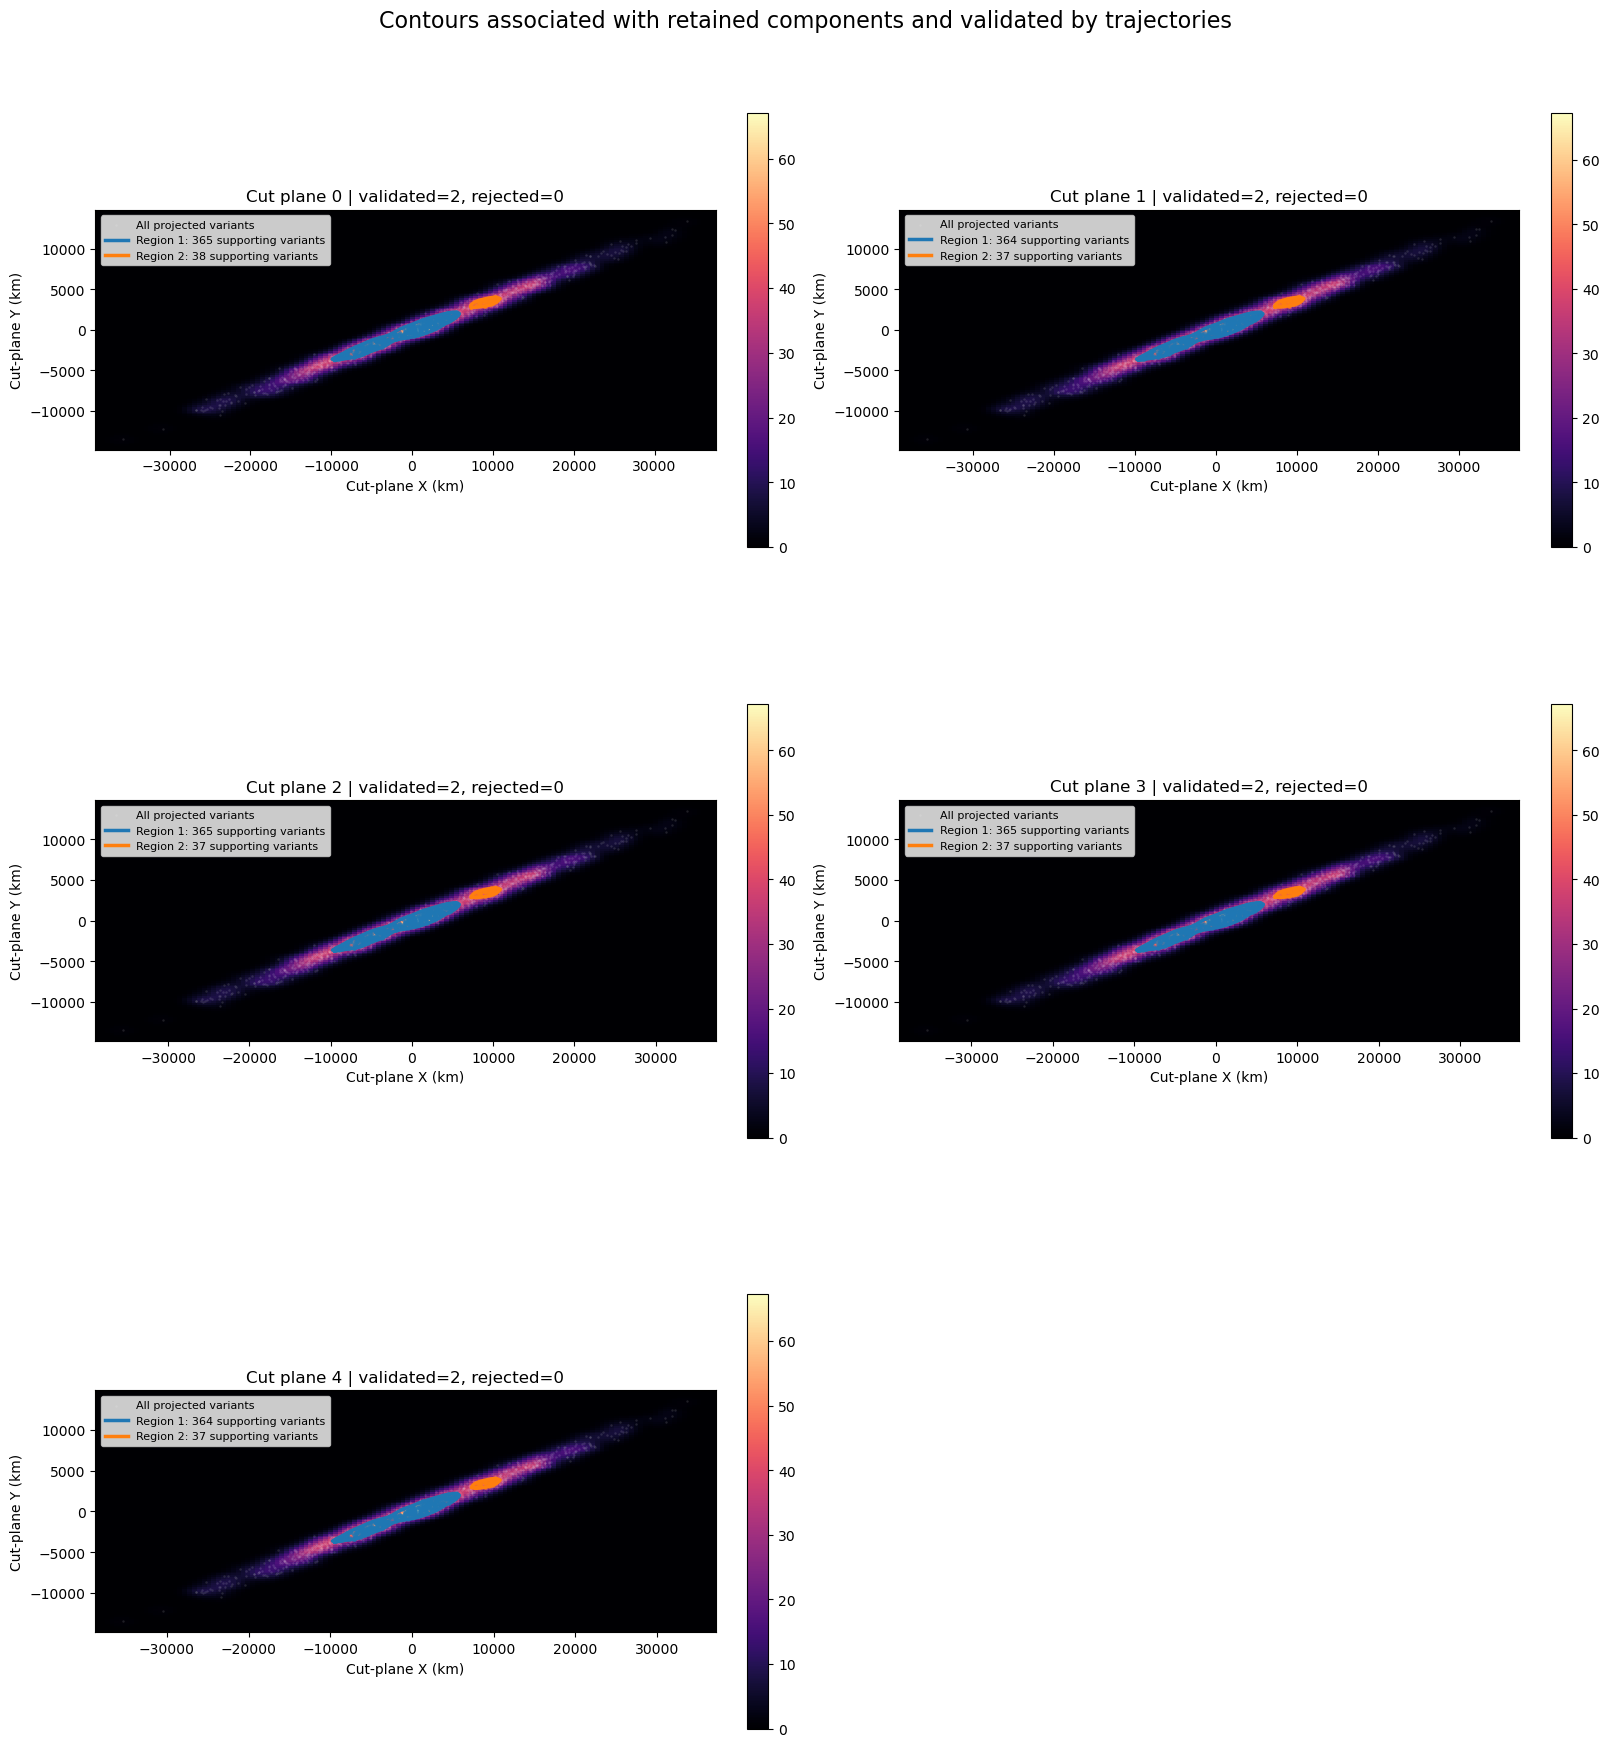

In [16]:
figure, axes = plt.subplots(
    3,
    2,
    figsize=(16, 18),
    constrained_layout=True,
)
axes = axes.ravel()

for axes_index, (analysis, validated, rejected) in enumerate(
    zip(
        first_five_density_results,
        first_five_validated_contours,
        first_five_rejected_contours,
    )
):
    ax = axes[axes_index]
    result = analysis.density
    extent = (*result.range_x, *result.range_y)
    density_image = ax.imshow(
        result.density_matrix,
        origin="lower",
        extent=extent,
        cmap="magma",
        aspect="equal",
        interpolation="nearest",
    )

    ax.scatter(
        analysis.points_2d_km[:, 0],
        analysis.points_2d_km[:, 1],
        s=3,
        color="white",
        alpha=0.12,
        linewidths=0,
        label="All projected variants",
    )

    for item in validated:
        vertices = item.contour.vertices_2d_km
        members = item.point_indices
        line = ax.plot(
            vertices[:, 0],
            vertices[:, 1],
            linewidth=2.5,
            label=(
                f"Region {item.region.label}: "
                f"{len(members)} supporting variants"
            ),
        )[0]
        ax.scatter(
            analysis.points_2d_km[members, 0],
            analysis.points_2d_km[members, 1],
            s=10,
            color=line.get_color(),
            alpha=0.75,
            linewidths=0,
        )

    for contour_index, contour in enumerate(rejected, start=1):
        vertices = contour.vertices_2d_km
        ax.plot(
            vertices[:, 0],
            vertices[:, 1],
            linestyle="--",
            color="gray",
            linewidth=1.5,
            label="Rejected contour" if contour_index == 1 else None,
        )

    ax.set_title(
        f"Cut plane {analysis.cutplane_index} | "
        f"validated={len(validated)}, rejected={len(rejected)}"
    )
    ax.set_xlabel("Cut-plane X (km)")
    ax.set_ylabel("Cut-plane Y (km)")
    ax.legend(loc="best", fontsize=8)
    figure.colorbar(density_image, ax=ax, shrink=0.75)

for unused_axes in axes[len(first_five_density_results):]:
    unused_axes.set_visible(False)

figure.suptitle(
    "Contours associated with retained components and validated by trajectories",
    fontsize=16,
)
plt.show()

## Inspect correspondence between two consecutive cut planes

Set `correspondence_cutplane_index` to the first tube cut-plane index you want to inspect. The next cached time slice is selected automatically. Correspondence uses only stable variant-ID membership: `overlap = shared IDs / size of the smaller region`. Jaccard is not used. All pairs above the overlap and shared-count thresholds are retained, so the result can show one-to-one continuations, splits, and merges.

In [26]:
from density_tube_generation import (
    analyze_density_cache_index,
    associate_and_validate_contours,
    extract_iso_density_contours,
    match_validated_contours,
    variant_id_overlap,
)


# Change this value to inspect a different pair of consecutive time slices.
correspondence_cutplane_index = 180
correspondence_mass_fraction = 0.3
correspondence_minimum_region_members = 5
correspondence_full_opacity_region_members = 10
correspondence_minimum_overlap = 0.5
correspondence_minimum_shared_variants = 5

matching_cache_rows = np.flatnonzero(
    cutplane_indices == correspondence_cutplane_index
)
if len(matching_cache_rows) != 1:
    raise ValueError(
        f"Expected exactly one cached row for cut plane "
        f"{correspondence_cutplane_index}; found {len(matching_cache_rows)}"
    )

source_cache_index = int(matching_cache_rows[0])
target_cache_index = source_cache_index + 1
if target_cache_index >= len(cutplane_indices):
    raise IndexError("The selected cut plane has no following cached time slice")
if not np.any(valid_by_time[source_cache_index]):
    raise ValueError("The selected source cache row has no valid variant states")
if not np.any(valid_by_time[target_cache_index]):
    raise ValueError("The following cache row has no valid variant states")

correspondence_analyses = [
    analyze_density_cache_index(
        cache_index,
        cutplanes,
        cutplane_indices,
        positions_km,
        velocities_km_s,
        target_ids,
        mass_fraction=correspondence_mass_fraction,
        resolution=128,
        minimum_region_members=correspondence_minimum_region_members,
    )
    for cache_index in (source_cache_index, target_cache_index)
]

correspondence_validated = []
for pair_analysis in correspondence_analyses:
    pair_contours = extract_iso_density_contours(pair_analysis.density)
    validated, rejected = associate_and_validate_contours(
        pair_contours,
        pair_analysis.density,
        pair_analysis.points_2d_km,
        pair_analysis.target_ids,
        minimum_points=correspondence_minimum_region_members,
    )
    validated_by_label = {}
    for item in validated:
        label = item.region.label
        if (
            label not in validated_by_label
            or len(item.point_indices) > len(validated_by_label[label].point_indices)
        ):
            validated_by_label[label] = item
    validated = [validated_by_label[label] for label in sorted(validated_by_label)]
    correspondence_validated.append(validated)

correspondence_matches = match_validated_contours(
    correspondence_validated[0],
    correspondence_validated[1],
    minimum_overlap=correspondence_minimum_overlap,
    minimum_shared_variants=correspondence_minimum_shared_variants,
)

print(
    f"Cut plane {correspondence_analyses[0].cutplane_index} -> "
    f"{correspondence_analyses[1].cutplane_index}"
)
for match in correspondence_matches:
    print(
        f"Region {match.source_label} -> Region {match.target_label}: "
        f"shared={match.shared_variant_count}, "
        f"overlap={match.overlap_smaller:.1%}, "
        f"source fraction={match.source_fraction:.1%}, "
        f"target fraction={match.target_fraction:.1%}"
    )

Cut plane 180 -> 181
Region 1 -> Region 1: shared=321, overlap=87.0%, source fraction=87.0%, target fraction=69.6%


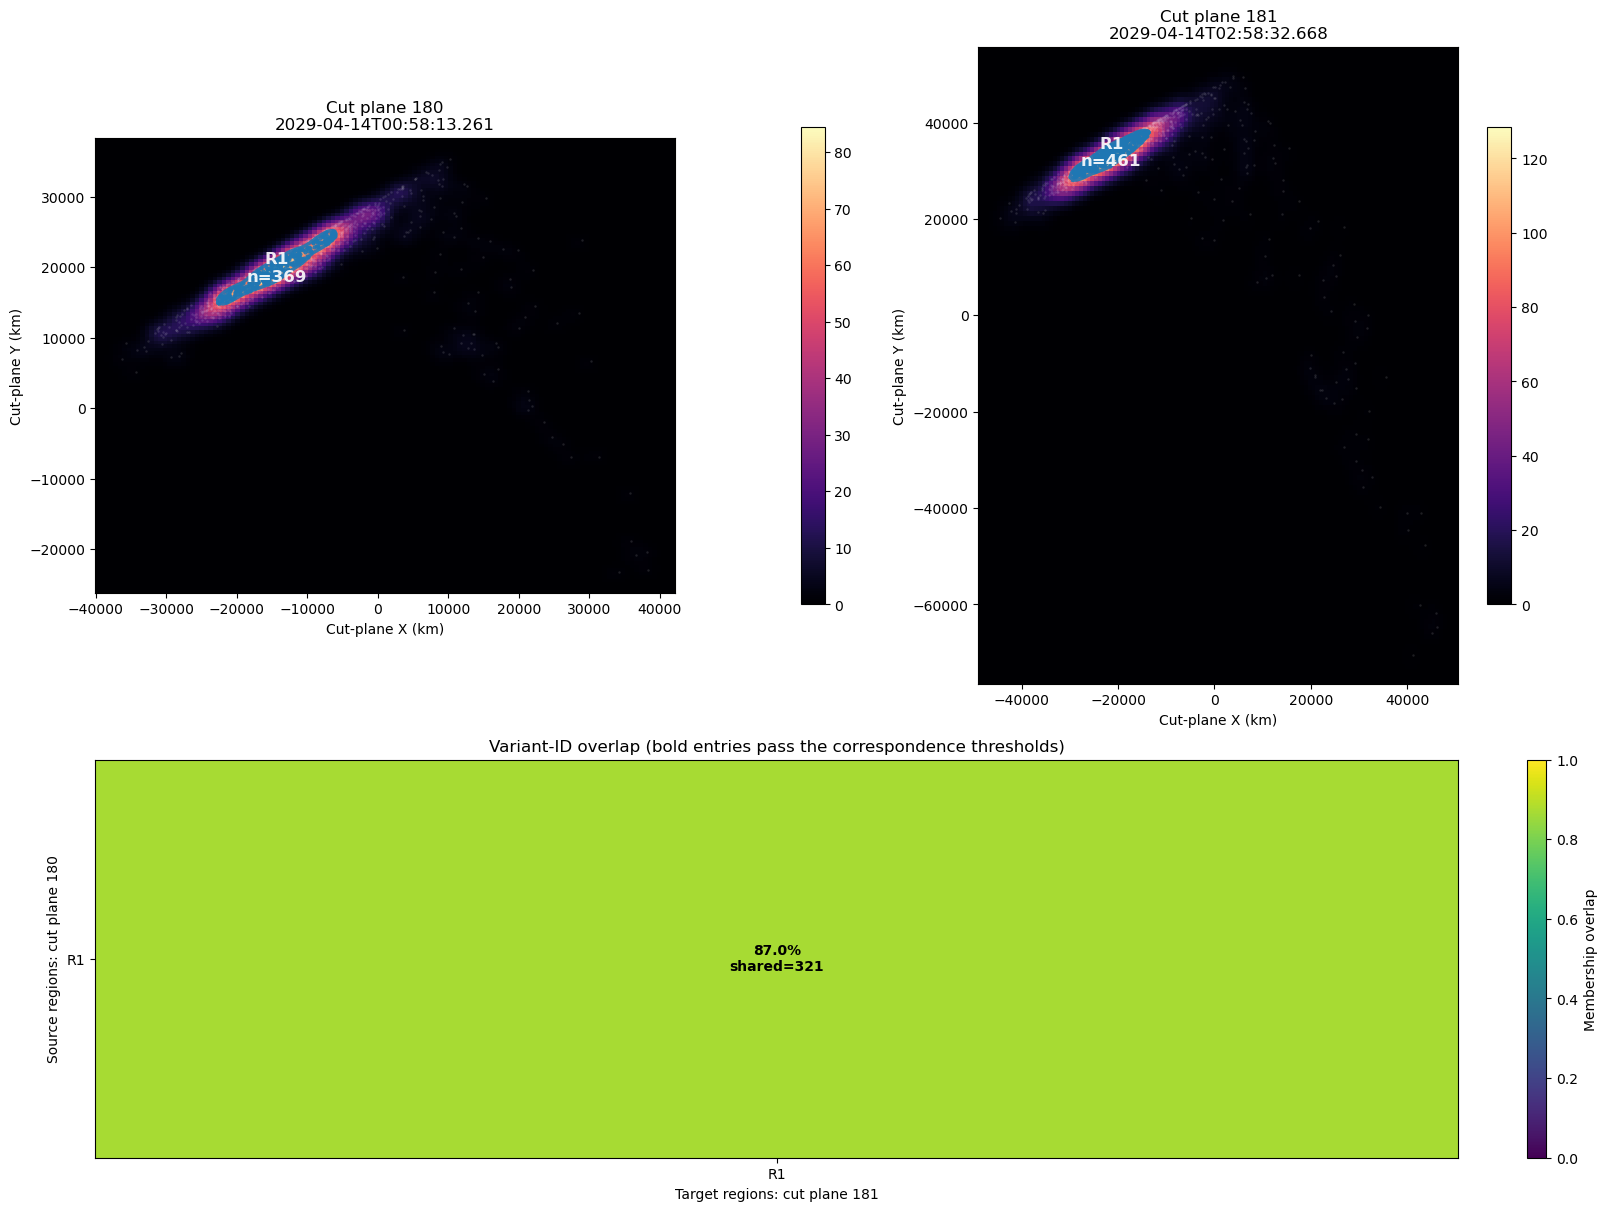

In [27]:
source_regions = correspondence_validated[0]
target_regions = correspondence_validated[1]
source_labels = [item.region.label for item in source_regions]
target_labels = [item.region.label for item in target_regions]
overlap_matrix = np.zeros((len(source_regions), len(target_regions)))
shared_matrix = np.zeros_like(overlap_matrix, dtype=int)

for source_index, source_item in enumerate(source_regions):
    for target_index, target_item in enumerate(target_regions):
        shared, source_fraction, target_fraction, overlap = variant_id_overlap(
            source_item.target_ids, target_item.target_ids
        )
        overlap_matrix[source_index, target_index] = overlap
        shared_matrix[source_index, target_index] = shared

figure = plt.figure(figsize=(16, 12), constrained_layout=True)
grid_spec = figure.add_gridspec(2, 2, height_ratios=[2.0, 1.25])
slice_axes = [figure.add_subplot(grid_spec[0, 0]), figure.add_subplot(grid_spec[0, 1])]
matrix_axes = figure.add_subplot(grid_spec[1, :])

for ax, pair_analysis, validated in zip(
    slice_axes, correspondence_analyses, correspondence_validated
):
    result = pair_analysis.density
    density_image = ax.imshow(
        result.density_matrix,
        origin="lower",
        extent=(*result.range_x, *result.range_y),
        cmap="magma",
        aspect="equal",
        interpolation="nearest",
    )
    ax.scatter(
        pair_analysis.points_2d_km[:, 0],
        pair_analysis.points_2d_km[:, 1],
        s=3, color="white", alpha=0.12, linewidths=0,
    )
    for item in validated:
        color = f"C{(item.region.label - 1) % 10}"
        vertices = item.contour.vertices_2d_km
        members = item.point_indices
        component_alpha = (
            0.35
            if len(members) < correspondence_full_opacity_region_members
            else 0.9
        )
        ax.plot(
            vertices[:, 0], vertices[:, 1],
            color=color, linewidth=2.5, alpha=component_alpha,
        )
        ax.scatter(
            pair_analysis.points_2d_km[members, 0],
            pair_analysis.points_2d_km[members, 1],
            s=9, color=color, alpha=component_alpha, linewidths=0,
        )
        ax.text(
            item.region.centroid_2d[0],
            item.region.centroid_2d[1],
            f"R{item.region.label}\nn={len(members)}",
            color="white", alpha=component_alpha,
            fontsize=12, fontweight="bold",
            ha="center", va="center",
        )
    ax.set_title(
        f"Cut plane {pair_analysis.cutplane_index}\n"
        f"{pair_analysis.cutplane.time_utc}"
    )
    ax.set_xlabel("Cut-plane X (km)")
    ax.set_ylabel("Cut-plane Y (km)")
    figure.colorbar(density_image, ax=ax, shrink=0.75)

if overlap_matrix.size:
    overlap_image = matrix_axes.imshow(
        overlap_matrix, cmap="viridis", vmin=0.0, vmax=1.0, aspect="auto"
    )
    accepted_pairs = {
        (match.source_label, match.target_label) for match in correspondence_matches
    }
    for row, source_label in enumerate(source_labels):
        for column, target_label in enumerate(target_labels):
            accepted = (source_label, target_label) in accepted_pairs
            matrix_axes.text(
                column, row,
                f"{overlap_matrix[row, column]:.1%}\n"
                f"shared={shared_matrix[row, column]}",
                ha="center", va="center",
                color="white" if overlap_matrix[row, column] < 0.65 else "black",
                fontweight="bold" if accepted else "normal",
            )
    matrix_axes.set_xticks(range(len(target_labels)), [f"R{label}" for label in target_labels])
    matrix_axes.set_yticks(range(len(source_labels)), [f"R{label}" for label in source_labels])
    figure.colorbar(overlap_image, ax=matrix_axes, label="Membership overlap")
else:
    matrix_axes.text(0.5, 0.5, "No validated region pairs", ha="center", va="center")
    matrix_axes.set_xticks([])
    matrix_axes.set_yticks([])

matrix_axes.set_title(
    "Variant-ID overlap (bold entries pass the correspondence thresholds)"
)
matrix_axes.set_xlabel(
    f"Target regions: cut plane {correspondence_analyses[1].cutplane_index}"
)
matrix_axes.set_ylabel(
    f"Source regions: cut plane {correspondence_analyses[0].cutplane_index}"
)
plt.show()

## Region evolution over UTC time

This visualization separates **local connected components** from **persistent region lineages**. A local label such as `C2` is assigned independently on one cut plane and has no temporal meaning. A persistent label such as `R2` follows a trajectory population through time using stable variant target IDs.

### Parameters

- Cut-plane window: `evolution_start_cutplane_index = 145` through `evolution_end_cutplane_index = 180`, inclusive.
- Highest-density mass fraction: `evolution_mass_fraction = 0.3`. The retained density mask contains approximately the densest 30% of the smoothed density mass on each cut plane.
- Density-grid resolution: `128` by `128`.
- Minimum component support: `evolution_minimum_region_members = 5`. Components with fewer than five supporting trajectories are excluded. This threshold is applied during density-component detection and again after geometric contour validation.
- Full-opacity support: `evolution_full_opacity_region_members = 10`. Components with 5–9 validated trajectories are retained but drawn faintly; components with at least 10 are drawn at full opacity.
- Minimum membership overlap: `evolution_minimum_overlap = 0.5`. For memberships $A$ and $B$, overlap is $|A \cap B| / \min(|A|, |B|)$, so at least half of the smaller membership must be shared.
- Minimum shared trajectories: `evolution_minimum_shared_variants = 5`. A match must share at least five stable target IDs in addition to passing the 50% overlap threshold.
- Identity lookback: `evolution_lineage_lookback_slices = 5`. A newly detected component is compared with lineage fingerprints seen during the preceding five slices.
- Disappearance tolerance: `evolution_disappearance_gap_slices = 2`. A lineage is visually considered disappeared after more than two consecutive missing slices. Its fingerprint is nevertheless retained for the full five-slice lookback, so a later qualifying component can recover the same persistent ID.

### Per-slice component detection

1. Intersect every valid propagated trajectory with the current cut plane and project the intersection into two dimensions.
2. Generate the smoothed density texture on a 128 by 128 grid.
3. Select the grid cells belonging to the highest-density 30% of the total density mass.
4. Label eight-connected regions in that binary mask. These labels are local (`C1`, `C2`, ...) and are recalculated independently at every slice.
5. Reject components with fewer than five assigned trajectories.
6. Extract continuous iso-density contours and require supporting trajectories to have the component's grid label and lie geometrically inside its contour. Reject contours with fewer than five validated trajectories.
7. If multiple contours are associated with the same local component, retain only the contour with the strongest trajectory support so that one physical component is tracked once.

### Persistent-lineage matching

1. At the first slice, assign a new persistent ID (`R1`, `R2`, ...) to every validated component.
2. For each later component, compare its stable trajectory IDs with every lineage eligible within the five-slice lookback. Normally a lineage fingerprint is its most recent distinct component membership.
3. Accept a candidate only when `overlap_smaller >= 0.5` and `shared_variant_count >= 5`.
4. Assign each lineage to its strongest qualifying component, ranked by overlap, shared count, and target-membership fraction. One lineage can continue into only one component, but one component can inherit several lineages.
5. If no eligible lineage matches a component, assign the next unused persistent ID and mark it as new.

### Merges, splits, gaps, and recovery

- **Merge:** If several lineages select the same local component, that component carries all of their IDs, for example `C1: R1+R2`. The largest earlier component determines the dominant display lane. Smaller lineages connect diagonally into the merged node.
- **Fingerprint preservation during a merge:** Each lineage retains its last distinct, pre-merge membership rather than replacing it with the complete merged membership.
- **Split or re-emergence:** If a merged component later separates, each child is compared with the saved lineage fingerprints. A qualifying child recovers the corresponding original ID. In the graph, a line diverging from a merged node shows this event.
- **Temporary gap:** A direct edge can span missing cut planes when a lineage is recovered within five slices. The gap means no component met the detection and validation requirements at the intervening slices; it does not necessarily mean the physical trajectory population ceased to exist.
- **Disappearance:** A red `x` is used when the lineage has no detected continuation within the allowed two-missing-slice tolerance. Because identity memory lasts five slices, the same ID can still be recovered later if the membership criteria pass.

### Visual encoding

- Horizontal position is the cut plane's UTC timestamp.
- The vertical lanes are persistent lineage IDs (`Region 1`, `Region 2`, ...), not local connected-component labels.
- Each circle is one detected local component. Node size increases with its validated trajectory count.
- A faint node has 5–9 validated trajectories; a high-opacity node has at least 10.
- A star marks a component assigned a genuinely new persistent lineage.
- A node annotation such as `C2: R3` reports the local component label and its persistent lineage. A composite annotation such as `C1: R1+R2` reports a merge.
- Edge color identifies the lineage being followed. Edge width and opacity increase with `overlap_smaller`.
- Diagonal convergence into one node indicates a merge. Diagonal divergence from a shared node indicates a split or lineage re-emergence.
- A long edge spanning several timestamps indicates recovery after a temporary detection gap.

In [19]:
from datetime import datetime

from density_tube_generation import build_region_evolution_graph


# Inclusive cut-plane range. This default window includes the change near 155 -> 156.
evolution_start_cutplane_index = 145
evolution_end_cutplane_index = 180
evolution_mass_fraction = 0.3
evolution_minimum_region_members = 5
evolution_full_opacity_region_members = 10
evolution_minimum_shared_variants = 5
evolution_minimum_overlap = 0.5  # Shared IDs / size of the smaller region.
evolution_lineage_lookback_slices = 5
evolution_disappearance_gap_slices = 2

if evolution_end_cutplane_index < evolution_start_cutplane_index:
    raise ValueError("evolution_end_cutplane_index must not precede the start")

evolution_cache_indices = [
    cache_index
    for cache_index, cutplane_index in enumerate(cutplane_indices)
    if (
        evolution_start_cutplane_index <= int(cutplane_index) <= evolution_end_cutplane_index
        and np.any(valid_by_time[cache_index])
    )
]
if len(evolution_cache_indices) < 2:
    raise ValueError("The selected range must contain at least two valid cached slices")

evolution_analyses = []
evolution_validated_slices = []
for cache_index in evolution_cache_indices:
    slice_analysis = analyze_density_cache_index(
        cache_index,
        cutplanes,
        cutplane_indices,
        positions_km,
        velocities_km_s,
        target_ids,
        mass_fraction=evolution_mass_fraction,
        resolution=128,
        minimum_region_members=evolution_minimum_region_members,
    )
    slice_contours = extract_iso_density_contours(slice_analysis.density)
    validated, rejected = associate_and_validate_contours(
        slice_contours,
        slice_analysis.density,
        slice_analysis.points_2d_km,
        slice_analysis.target_ids,
        minimum_points=evolution_minimum_region_members,
    )
    # A component can occasionally be enclosed by more than one contour.
    # Track it once, using the contour with the strongest point support.
    validated_by_label = {}
    for item in validated:
        label = item.region.label
        if (
            label not in validated_by_label
            or len(item.point_indices) > len(validated_by_label[label].point_indices)
        ):
            validated_by_label[label] = item
    validated = [validated_by_label[label] for label in sorted(validated_by_label)]
    evolution_analyses.append(slice_analysis)
    evolution_validated_slices.append(validated)

region_evolution_graph = build_region_evolution_graph(
    evolution_validated_slices,
    minimum_overlap=evolution_minimum_overlap,
    minimum_shared_variants=evolution_minimum_shared_variants,
    lineage_lookback_slices=evolution_lineage_lookback_slices,
)
evolution_times = [
    datetime.fromisoformat(analysis.cutplane.time_utc.replace("Z", "+00:00"))
    for analysis in evolution_analyses
]

lineage_edge_count = sum(
    len(matches)
    for matches in region_evolution_graph.lineage_matches_by_transition
)
merge_node_count = sum(
    len(node.lineage_ids) > 1 for node in region_evolution_graph.nodes
)
new_lineage_count = sum(
    len(node.new_lineage_ids) for node in region_evolution_graph.nodes
)
persistent_lineage_count = max(
    (lineage_id for node in region_evolution_graph.nodes for lineage_id in node.lineage_ids),
    default=0,
)
print(
    f"Analyzed {len(evolution_analyses)} slices from "
    f"{evolution_times[0]} to {evolution_times[-1]}"
)
print(
    f"Components={len(region_evolution_graph.nodes)}, "
    f"persistent lineages={persistent_lineage_count}, "
    f"lineage edges={lineage_edge_count}, "
    f"merged components={merge_node_count}, new lineages={new_lineage_count}"
)

Analyzed 36 slices from 2029-04-11 02:46:54.016000 to 2029-04-14 00:58:13.261000
Components=86, persistent lineages=5, lineage edges=89, merged components=7, new lineages=5


In [20]:
# Report validated trajectory membership for every region in the evolution window.
evolution_region_sizes = []
for slice_index, validated in enumerate(evolution_validated_slices):
    cutplane_index = evolution_analyses[slice_index].cutplane_index
    time_utc = evolution_analyses[slice_index].cutplane.time_utc
    slice_sizes = []
    for item in validated:
        member_count = len(item.point_indices)
        evolution_region_sizes.append(
            (member_count, cutplane_index, time_utc, item.region.label)
        )
        slice_sizes.append(f"R{item.region.label}={member_count}")
    print(
        f"Cut plane {cutplane_index} | {time_utc} | "
        + (", ".join(slice_sizes) if slice_sizes else "no validated regions")
    )

region_size_values = np.asarray(
    [row[0] for row in evolution_region_sizes], dtype=int
)
if region_size_values.size:
    print("\nValidated region-size summary")
    print(f"Regions: {region_size_values.size}")
    print(
        f"Range: {region_size_values.min()}–{region_size_values.max()} variants"
    )
    print(
        f"Median: {np.median(region_size_values):.1f}, "
        f"mean: {region_size_values.mean():.1f}"
    )
    print(
        "Percentiles (10/25/50/75/90):",
        np.percentile(region_size_values, [10, 25, 50, 75, 90]),
    )
    print("Smallest regions (members, cut plane, UTC, local label):")
    for row in sorted(evolution_region_sizes)[:10]:
        print(row)
else:
    print("No validated regions in the selected evolution window.")

Cut plane 145 | 2029-04-11T02:46:54.016 | R1=327, R2=28
Cut plane 146 | 2029-04-11T04:47:13.423 | R1=324, R2=26
Cut plane 147 | 2029-04-11T06:47:32.830 | R1=326, R2=26
Cut plane 148 | 2029-04-11T08:47:52.237 | R1=333, R2=27
Cut plane 149 | 2029-04-11T10:48:11.644 | R1=325, R2=27
Cut plane 150 | 2029-04-11T12:48:31.051 | R1=322, R2=28
Cut plane 151 | 2029-04-11T14:48:50.458 | R1=321, R2=28, R3=5
Cut plane 152 | 2029-04-11T16:49:09.865 | R1=325, R2=29, R3=7
Cut plane 153 | 2029-04-11T18:49:29.272 | R1=323, R2=28, R3=6
Cut plane 154 | 2029-04-11T20:49:48.679 | R1=319, R2=28
Cut plane 155 | 2029-04-11T22:50:08.086 | R1=317, R2=26, R3=5
Cut plane 156 | 2029-04-12T00:50:27.493 | R1=316, R2=26, R3=6
Cut plane 157 | 2029-04-12T02:50:46.900 | R1=320, R2=26, R3=6
Cut plane 158 | 2029-04-12T04:51:06.307 | R1=318, R2=27, R3=5
Cut plane 159 | 2029-04-12T06:51:25.714 | R1=309, R2=28, R3=5
Cut plane 160 | 2029-04-12T08:51:45.121 | R1=312, R2=27, R3=7
Cut plane 161 | 2029-04-12T10:52:04.528 | R1=311, 

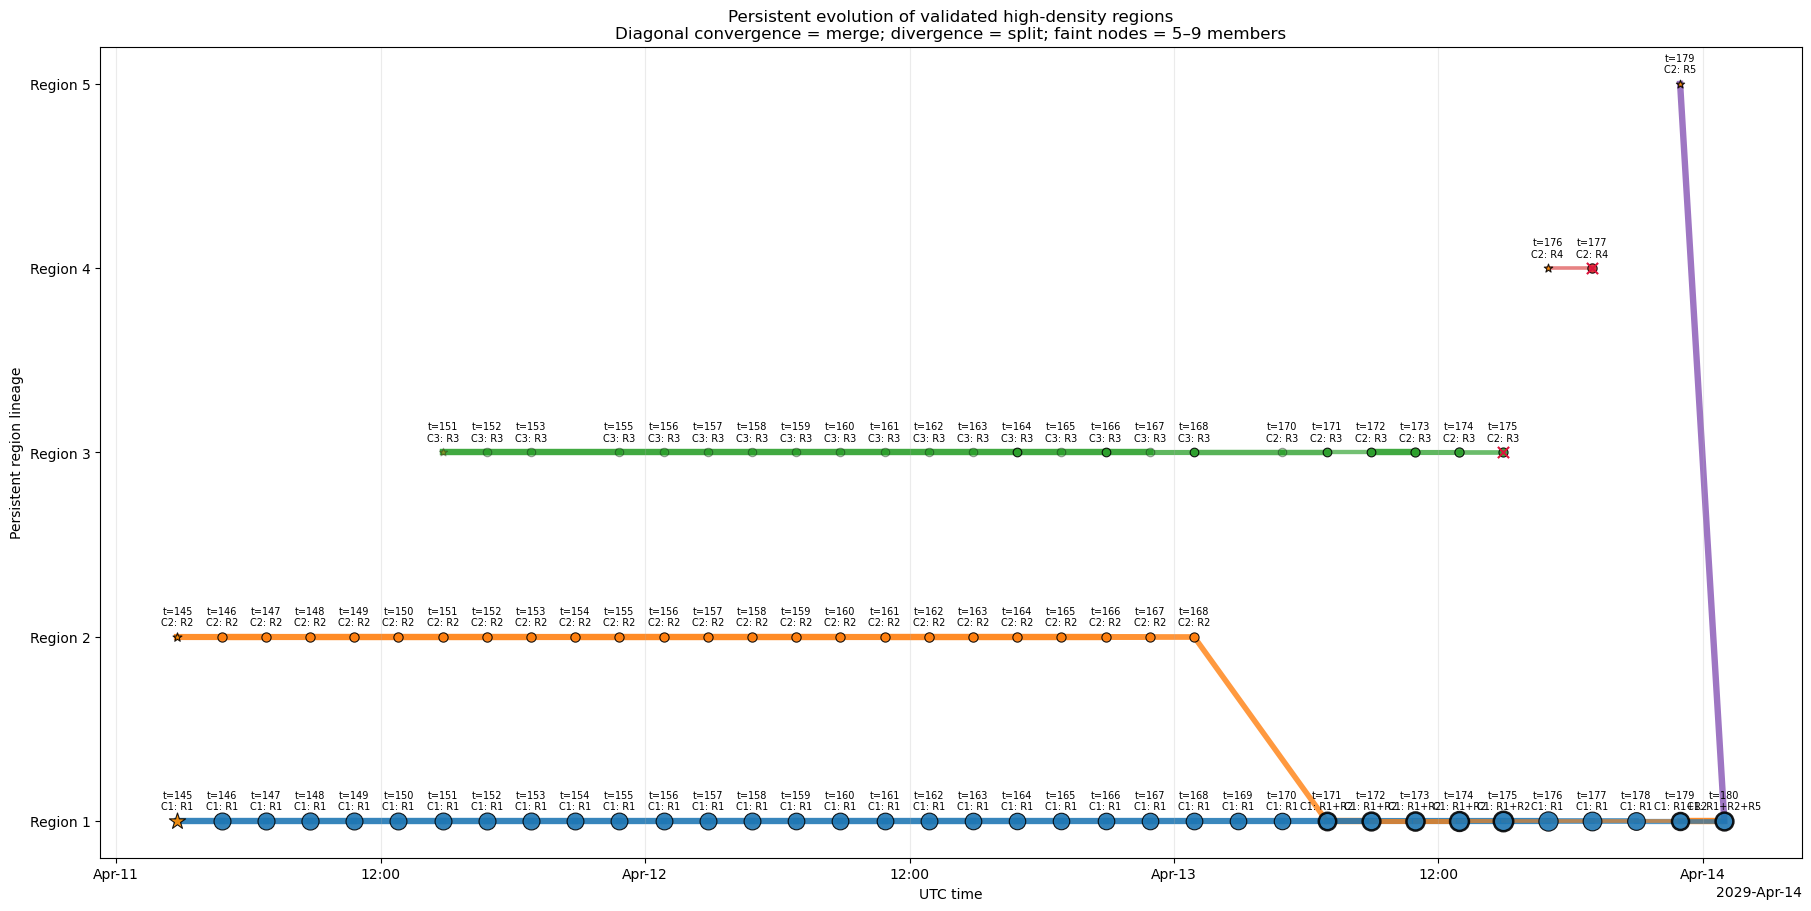

In [21]:
import matplotlib.dates as mdates


figure, axes = plt.subplots(figsize=(18, 9), constrained_layout=True)

# Place each detected component on its dominant lineage lane.  For a merged
# component, the dominant lineage is the one with the largest earlier
# component; smaller lineages connect diagonally into the merged node.
node_by_key = {
    (node.slice_index, node.region_label): node
    for node in region_evolution_graph.nodes
}
display_lineage_by_key = {}
for node in region_evolution_graph.nodes:
    previous_sizes = {
        lineage_id: max(
            (
                earlier.variant_count
                for earlier in region_evolution_graph.nodes
                if earlier.slice_index < node.slice_index
                and lineage_id in earlier.lineage_ids
            ),
            default=0,
        )
        for lineage_id in node.lineage_ids
    }
    display_lineage_by_key[(node.slice_index, node.region_label)] = max(
        node.lineage_ids,
        key=lambda lineage_id: (previous_sizes[lineage_id], -lineage_id),
    )

# Draw lineage-specific edges between component nodes.  Merge and split
# events are visible as diagonal lines entering or leaving a shared node.
for transition_index, matches in enumerate(
    region_evolution_graph.lineage_matches_by_transition
):
    target_time = evolution_times[transition_index + 1]
    for match in matches:
        source_time = evolution_times[match.source_slice_index]
        source_y = display_lineage_by_key[(match.source_slice_index, match.source_label)]
        target_y = display_lineage_by_key[(transition_index + 1, match.target_label)]
        axes.plot(
            [source_time, target_time],
            [source_y, target_y],
            color=f"C{(match.lineage_id - 1) % 10}",
            linewidth=0.6 + 4.0 * match.overlap_smaller,
            alpha=0.25 + 0.65 * match.overlap_smaller,
            zorder=1,
        )

# Draw exactly one circular node for each detected component.
for node in region_evolution_graph.nodes:
    slice_index = node.slice_index
    display_lineage = display_lineage_by_key[(slice_index, node.region_label)]
    is_new = bool(node.new_lineage_ids)
    near_future_lineages = {
        lineage_id
        for future in region_evolution_graph.nodes
        if (
            slice_index < future.slice_index
            <= slice_index + evolution_disappearance_gap_slices + 1
        )
        for lineage_id in future.lineage_ids
    }
    is_ending = not any(
        lineage_id in near_future_lineages for lineage_id in node.lineage_ids
    ) and slice_index < len(evolution_validated_slices) - 1
    color = "darkorange" if is_new else f"C{(display_lineage - 1) % 10}"
    component_alpha = (
        0.35
        if node.variant_count < evolution_full_opacity_region_members
        else 0.9
    )
    axes.scatter(
        [evolution_times[slice_index]],
        [display_lineage],
        s=35 + 0.35 * node.variant_count,
        marker="*" if is_new else "o",
        color=color,
        alpha=component_alpha,
        edgecolor="black",
        linewidth=1.8 if len(node.lineage_ids) > 1 else 0.8,
        zorder=3,
    )
    if is_ending:
        axes.scatter(
            [evolution_times[slice_index]], [display_lineage],
            s=65, marker="x", color="crimson", linewidth=1.5, zorder=4,
        )
    cutplane_index = evolution_analyses[slice_index].cutplane_index
    lineage_text = "+".join(f"R{value}" for value in node.lineage_ids)
    axes.annotate(
        f"t={cutplane_index}\nC{node.region_label}: {lineage_text}",
        (evolution_times[slice_index], display_lineage),
        xytext=(0, 8), textcoords="offset points",
        ha="center", fontsize=7,
    )

maximum_lineage_id = max(
    (lineage_id for node in region_evolution_graph.nodes for lineage_id in node.lineage_ids),
    default=1,
)
axes.set_yticks(
    range(1, maximum_lineage_id + 1),
    [f"Region {value}" for value in range(1, maximum_lineage_id + 1)],
)
axes.xaxis.set_major_locator(mdates.AutoDateLocator())
axes.xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes.xaxis.get_major_locator()))
axes.grid(axis="x", alpha=0.25)
axes.set_xlabel("UTC time")
axes.set_ylabel("Persistent region lineage")
axes.set_title(
    "Persistent evolution of validated high-density regions\n"
    "Diagonal convergence = merge; divergence = split; faint nodes = 5–9 members"
)
plt.show()